In [743]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import special
import pandas as pd
from scipy.optimize import curve_fit


In [744]:
df = pd.read_csv('planks.csv')
df.head()

,BLUE,Vin V,Vout V,A (microAmps),RED,Vin V .1,Vout V.1,A (microAmps).1,YELLOW,Vin V .2,...,Vout V.4,A (microAmps).4,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27
0,NaN,0.0,0.002,0.0,NaN,0.00,0.003,0.0,NaN,0.0,...,0.003,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,0.5,0.499,0.0,NaN,0.50,0.499,0.0,NaN,0.5,...,0.499,0.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,1.0,0.996,0.1,NaN,1.00,0.997,0.1,NaN,1.0,...,0.996,0.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,1.5,1.492,0.1,NaN,1.40,1.393,0.3,NaN,1.4,...,1.489,1.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,2.0,1.997,0.2,NaN,1.42,1.414,0.5,NaN,1.5,...,1.982,4.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [745]:
blue = df.iloc[:, 1:4]
blue = blue.dropna()
blue = blue.sort_values(by='Vin V ')
blue_copy = blue.copy()

red = df.iloc[:, 5:8]
red = red.dropna()
red = red.sort_values(by = 'Vin V .1')
red_copy = red.copy()


yellow = df.iloc[:, 9:12]
yellow = yellow.dropna()
yellow = yellow.drop([51,52,53,54])
yellow = yellow.sort_values(by = 'Vin V .2')
yellow_copy = yellow.copy()

green = df.iloc[:, 13:16]
green = green.dropna()
green = green.sort_values(by = 'Vin V .3')
green_copy = green.copy()

white = df.iloc[:, 17:20]
white = white.dropna()
white = white.sort_values(by = 'Vin V .4')
white_copy = white.copy()

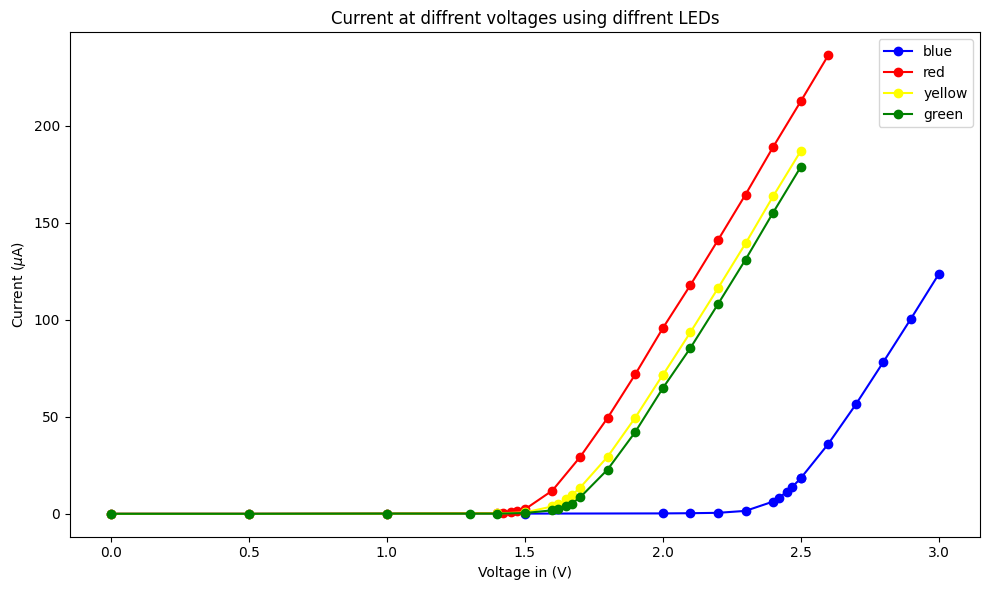

In [746]:
plt.figure(figsize =(10,6))

plt.plot(blue['Vin V '], blue['A (microAmps)'], label = 'blue', color ='blue', marker='o')
plt.plot(red['Vin V .1'], red['A (microAmps).1'], label = 'red', color = 'red',marker='o')
plt.plot(yellow['Vin V .2'], yellow['A (microAmps).2'], label = 'yellow', color = 'yellow', marker='o')
plt.plot(green['Vin V .3'], green['A (microAmps).3'], label = 'green', color = 'green', marker='o')
#plt.plot(white['Vin V .4'], white['A (microAmps).4'], label = 'white', color = 'black', marker='o')
plt.legend()
plt.xlabel('Voltage in (V)')
plt.ylabel(r'Current ($\mu$A)')
plt.title('Current at diffrent voltages using diffrent LEDs')
plt.tight_layout()
plt.show()

In [747]:
#remove all zero readings
blue = blue[blue['A (microAmps)'] > 1.5]
blue = blue.drop([8, 9, 10,11, 12])
green = green[green['A (microAmps).3'] > 1.5]
green = green.drop([6,7,8,9,10]) # removing outlier
red = red[red['A (microAmps).1'] > 1.5]
red = red.drop([7,8, 9,18, 17]) # removing outlier
yellow = yellow[yellow['A (microAmps).2'] > 1.5]
yellow = yellow.drop([5,6,7,8,9, 10]) # removing outlier

# fitting 
def f(x, m, b):
    return m*x + b

popt_blue, _ = curve_fit(f, blue['Vin V '], blue['A (microAmps)'])
popt_green, _ = curve_fit(f, green['Vin V .3'], green['A (microAmps).3'])
popt_red, _ = curve_fit(f, red['Vin V .1'], red['A (microAmps).1'])
popt_yellow, _ = curve_fit(f, yellow['Vin V .2'], yellow['A (microAmps).2'])

Va_blue = -popt_blue[1] / popt_blue[0]    
Va_green = -popt_green[1] / popt_green[0]
Va_red = -popt_red[1] / popt_red[0]
Va_yellow = -popt_yellow[1] / popt_yellow[0]

print(f"Activation Voltage (Blue):   {Va_blue:.3f} V")
print(f"Activation Voltage (Green):  {Va_green:.3f} V")
print(f"Activation Voltage (Red):    {Va_red:.3f} V")
print(f"Activation Voltage (Yellow): {Va_yellow:.3f} V")


Activation Voltage (Blue):   2.425 V
Activation Voltage (Green):  1.710 V
Activation Voltage (Red):    1.589 V
Activation Voltage (Yellow): 1.689 V


In [748]:
blue

,Vin V,Vout V,A (microAmps)
13,2.5,2.421,18.3
14,2.6,2.451,36.0
15,2.7,2.470,56.4
16,2.8,2.483,78.3
17,2.9,2.494,100.6
18,3.0,2.503,123.4


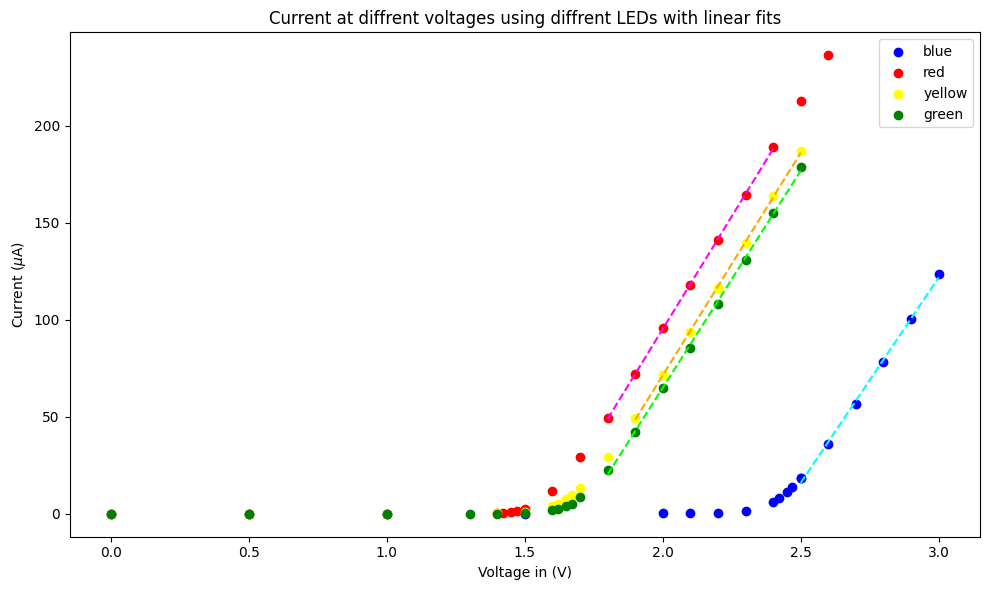

In [749]:
#visualize the curves with fits
plt.figure(figsize =(10,6))
plt.scatter(blue_copy['Vin V '], blue_copy['A (microAmps)'], label = 'blue', color ='blue', marker='o')
plt.scatter(red_copy['Vin V .1'], red_copy['A (microAmps).1'], label = 'red', color = 'red',marker='o')
plt.scatter(yellow_copy['Vin V .2'], yellow_copy['A (microAmps).2'], label = 'yellow', color = 'yellow', marker='o')
plt.scatter(green_copy['Vin V .3'], green_copy['A (microAmps).3'], label = 'green', color = 'green', marker='o')


plt.plot(blue['Vin V '], f(blue['Vin V '], *popt_blue), color='cyan', linestyle='--')
plt.plot(red['Vin V .1'], f(red['Vin V .1'], *popt_red), color='magenta', linestyle='--')
plt.plot(yellow['Vin V .2'], f(yellow['Vin V .2'], *popt_yellow), color='orange', linestyle='--')
plt.plot(green['Vin V .3'], f(green['Vin V .3'], *popt_green), color='lime', linestyle='--')
plt.legend()
plt.xlabel('Voltage in (V)')
plt.ylabel(r'Current ($\mu$A)')
plt.title('Current at diffrent voltages using diffrent LEDs with linear fits')
plt.tight_layout()
plt.show()

In [750]:
#calculate h
e = 1.6022e-19  
c = 2.9979e8         
lam_blue = 495e-9   
lam_green = 570e-9 
lam_red = 750e-9    
lam_yellow = 595e-9 

h_theo = 6.626e-34

h_blue = (e * Va_blue * lam_blue) / c
h_green = (e * Va_green * lam_green) / c
h_red = (e * Va_red * lam_red) / c
h_yellow = (e * Va_yellow * lam_yellow) / c

#error calculation
error_blue = abs((h_blue - h_theo) / h_theo) * 100
error_green = abs((h_green - h_theo) / h_theo) * 100
error_red = abs((h_red - h_theo) / h_theo) * 100
error_yellow = abs((h_yellow - h_theo) / h_theo) * 100

print(f"Calculated Planck's constant (Blue):   {h_blue:.3e} J·s, Error: {error_blue:.2f}%")
print(f"Calculated Planck's constant (Green):  {h_green:.3e} J·s, Error: {error_green:.2f}%")
print(f"Calculated Planck's constant (Red):    {h_red:.3e} J·s, Error: {error_red:.2f}%")
print(f"Calculated Planck's constant (Yellow): {h_yellow:.3e} J·s, Error: {error_yellow:.2f}%")

Calculated Planck's constant (Blue):   6.415e-34 J·s, Error: 3.18%
Calculated Planck's constant (Green):  5.208e-34 J·s, Error: 21.40%
Calculated Planck's constant (Red):    6.371e-34 J·s, Error: 3.85%
Calculated Planck's constant (Yellow): 5.370e-34 J·s, Error: 18.96%


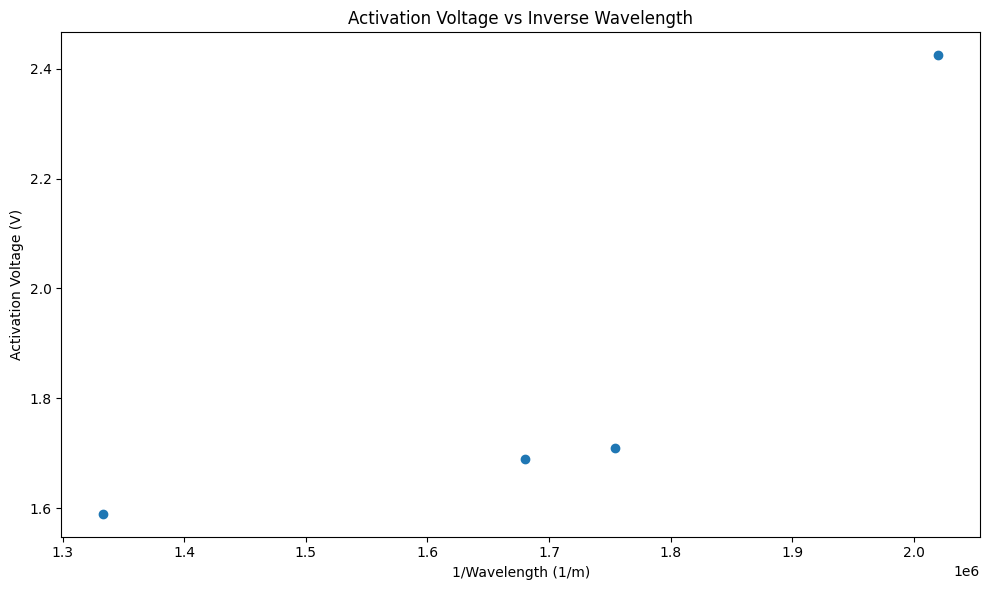

In [751]:
V_activation = [Va_blue, Va_green, Va_red, Va_yellow]
wavelengths = np.array([lam_blue, lam_green, lam_red, lam_yellow])
inverse_wavelengths = 1 / wavelengths

plt.figure(figsize =(10,6))
plt.plot(1/wavelengths, V_activation, marker='o', linestyle='None')
plt.xlabel('1/Wavelength (1/m)')
plt.ylabel('Activation Voltage (V)')
plt.title('Activation Voltage vs Inverse Wavelength')
plt.tight_layout()
plt.show()

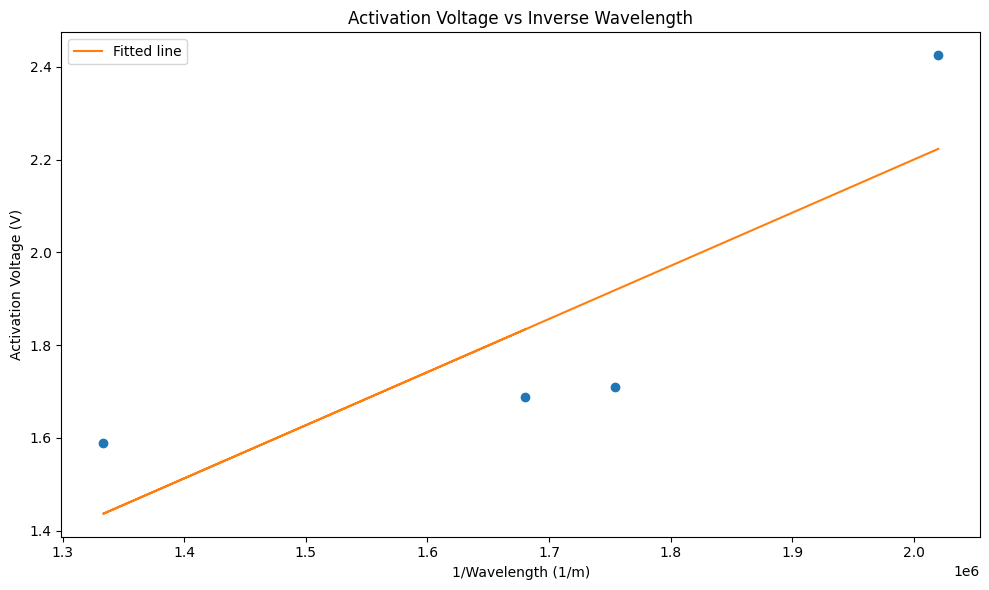

In [752]:
#join the data into one table
combined_df = pd.DataFrame({
    'Inverse Wavelength (m)': inverse_wavelengths,
    'Activation Voltage (V)': V_activation,
})

popt_comb, _ = curve_fit(f, combined_df['Inverse Wavelength (m)'], combined_df['Activation Voltage (V)'])

plt.figure(figsize =(10,6))
plt.plot(combined_df['Inverse Wavelength (m)'], combined_df['Activation Voltage (V)'], marker='o', linestyle='None')
plt.plot(combined_df['Inverse Wavelength (m)'], f(combined_df['Inverse Wavelength (m)'], *popt_comb), label='Fitted line')
plt.legend()
plt.xlabel('1/Wavelength (1/m)')
plt.ylabel('Activation Voltage (V)')
plt.title('Activation Voltage vs Inverse Wavelength')
plt.tight_layout()
plt.show()



In [753]:
h = (popt_comb[0]*e)/c
err = abs((h - h_theo) / h_theo) * 100

print(f"Calculated Planck's constant (Combined): {h:.3e} J·s, Error: {err:.2f}%")

Calculated Planck's constant (Combined): 6.120e-34 J·s, Error: 7.63%
